# XGBoost Pairwise Ranking for Recipe Recommendation

This notebook builds a query-level learning-to-rank pipeline with `XGBRanker(objective="rank:pairwise")`.
It uses only fields that already exist in this repository:

- `recipes_dataset_ver1.csv` for query-candidate labels
- `recipes_processed.json` for recipe metadata

The notebook:
1. Loads and merges the ranking labels with recipe metadata
2. Engineers query-recipe matching features
3. Splits the data by query to avoid leakage
4. Trains an XGBoost pairwise ranker
5. Evaluates with `NDCG`, `MRR`, and `HIT`
6. Shows feature importance and a small ablation
        


## I. Libraries Used

This notebook uses both Python standard libraries and machine learning/data analysis libraries to support data loading, preprocessing, feature engineering, model training, and evaluation.

- `json`, `os`: used for reading dataset files and handling file paths.
- `math`, `re`, `unicodedata`: used for mathematical calculations, regular expression matching, and Vietnamese text normalization.
- `time`: used to measure training and inference runtime.
- `Counter`, `defaultdict`: used for token counting and storing grouped evaluation results.
- `numpy`: used for numerical operations and array-based calculations.
- `pandas`: used for data loading, cleaning, merging, transformation, and tabular analysis.
- `matplotlib.pyplot`, `seaborn`: used for visualization such as feature importance plots, correlation heatmaps, and training curves.
- `TfidfVectorizer`: used to convert text into TF-IDF vectors for semantic similarity features.
- `ndcg_score`: used to evaluate ranking quality with NDCG.
- `cosine_similarity`: used to measure similarity between query and recipe text vectors.
- `train_test_split`: used to divide the data into train, validation, and test query groups.
- `XGBRanker`: the main learning-to-rank model used for pairwise recipe ranking.

The notebook also applies:
- `plt.style.use("seaborn-v0_8")` for cleaner plots
- `pd.set_option(...)` to display wider DataFrames more clearly
- `RANDOM_STATE = 42` to ensure reproducible results


In [14]:
import json
import math
import os
import re
import time
import unicodedata
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from xgboost import XGBRanker

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
        


## Machine Learning pipeline

### Step 1: Loads and merges the ranking labels with recipe metadata

In [15]:
labels_path = os.path.join("..", "dataset", "recipes_dataset_ver1.csv")
recipes_path = os.path.join("..", "dataset", "recipes_processed.json")

labels_df = pd.read_csv(labels_path, encoding="utf-8")

with open(recipes_path, "r", encoding="utf-8") as f:
    recipes = json.load(f)

recipes_df = pd.DataFrame(recipes).copy()
recipes_df["recipe_id"] = recipes_df.index.astype(int)

df = labels_df.merge(
    recipes_df,
    on=["recipe_id", "dish_name"],
    how="left",
    validate="many_to_one",
)

print("Ranking rows:", len(df))
print("Unique queries:", df["query"].nunique())
print("Candidates per query summary:")
print(df.groupby("query").size().describe())
print("\nMerged columns:")
print(df.columns.tolist())


Ranking rows: 3750
Unique queries: 250
Candidates per query summary:
count    250.0
mean      15.0
std        0.0
min       15.0
25%       15.0
50%       15.0
75%       15.0
max       15.0
dtype: float64

Merged columns:
['query', 'dish_name', 'recipe_id', 'label', 'reason', 'source', 'url', 'difficulty', 'views', 'ingredients', 'instructions', 'category', 'prep_time_min', 'cook_time_min', 'servings_bin', 'cook_time_source', 'popularity']


### Step 2: 2. Engineers query-recipe matching features

In [16]:
# =========================
# Query parsing helpers
# =========================

# STOPWORDS = các từ rất phổ biến, ít mang ý nghĩa nội dung, sẽ bỏ khi tokenize
STOPWORDS = {
    "toi", "la", "cho", "va", "1", "mon", "hay", "nao", "co", "khong", "thi",
    "de", "nau", "lam", "gi", "huong", "dan", "goi", "y", "can", "mot", "tu",
    "bang", "duoi", "tren", "deu", "nhung", "chi"
}

# POPULARITY_MAP = ánh xạ mức độ phổ biến từ text sang số
# Đang dùng trực tiếp để tạo feature rating
POPULARITY_MAP = {
    "Rất thấp": 1,
    "Thấp": 2,
    "Trung bình": 3,
    "Cao": 4,
    "Rất cao": 5,
}

# CATEGORY_KEYWORDS = từ khóa dùng để nhận diện loại món trong query
# Đang dùng trực tiếp cho category matching
CATEGORY_KEYWORDS = {
    "Mon nuong": ["nuong", "quay", "bbq"],
    "Mon canh": ["canh", "canh chua", "canh ngot"],
    "Mon chao": ["chao"],
    "Mon xao": ["xao"],
    "Mon kho": ["kho"],
    "Mon chien": ["chien", "ran", "gion"],
    "Mon hap": ["hap"],
    "Mon banh": ["banh", "panna cotta"],
    "Mon che": ["che"],
    "Mon nuoc": ["nuoc", "thuc uong", "do uong", "nuoc mat", "tra", "tra bi dao"],
    "Mon kem": ["kem"],
    "Mon goi - salad": ["goi", "salad", "tron"],
    "Mon bun": ["bun"],
    "Mon lau": ["lau"],
    "Mon chay": ["chay"],
    "Mon an vat": ["an vat", "nham nhi"],
    "Mon trang mieng": ["trang mieng"],
    "Mon kho mam": ["kho mam"],
    "Mon cuon - tron": ["cuon", "banh trang", "cuon tron"],
    "Sinh to": ["sinh to"],
    "Tra sua": ["tra sua"],
    "Nuoc ep": ["nuoc ep", "ep trai cay"],
    "Nuoc cham": ["nuoc cham", "nuoc mam cham", "sot", "sauce"],
    "Meo vao bep": ["meo", "bao quan", "so che", "khu mui"],
}

# DIFFICULTY_KEYWORDS = từ khóa để suy ra độ khó mong muốn từ query
# Đang dùng trực tiếp cho difficulty matching
DIFFICULTY_KEYWORDS = {
    1: ["de", "don gian", "nhanh", "it buoc", "nguoi moi", "de lam", "de nau", "de thanh cong"],
    2: ["trung binh", "vua tay", "hon mot chut"],
    3: ["kho", "thu suc", "cau ky", "tay nghe"],
}

# INTENT_KEYWORDS = nhóm từ khóa để nhận diện ý định, ngữ cảnh và phong cách món ăn
# Hiện chỉ dùng một phần:
# - "phong_cach" đang được dùng gián tiếp qua style_tags / wants_popular
# - các nhóm còn lại (loai_yeu_cau, dung_cu, doi_tuong, boi_canh) hiện CHƯA dùng trực tiếp trong feature_cols
INTENT_KEYWORDS = {
    "loai_yeu_cau": {
        "meo": ["meo", "bi kip"],
        "cong_thuc": ["cong thuc", "cach lam", "huong dan", "goi y", "chi toi"],
    },
    "dung_cu": {
        "noi_chien_khong_dau": ["noi chien khong dau"],
        "lo_nuong": ["lo nuong"],
        "lo_vi_song": ["lo vi song"],
    },
    "doi_tuong": {
        "cho_be": ["cho be", "tre em", "tre nho"],
        "nguoi_om": ["nguoi om"],
        "nguoi_moi": ["nguoi moi", "moi bat dau"],
        "gia_dinh": ["gia dinh", "bua com gia dinh"],
        "dai_khach": ["dai khach", "tiep khach"],
    },
    "boi_canh": {
        "cuoi_tuan": ["cuoi tuan"],
        "tet": ["tet", "dau nam", "ngay le tet", "mam co tet"],
        "ngay_nong": ["ngay nong", "mua he", "giai nhiet"],
        "troi_mua": ["troi mua", "buoi toi mua"],
        "buoi_sang": ["buoi sang", "bua sang"],
        "buoi_toi": ["buoi toi", "bua toi"],
    },
    "phong_cach": {
        "lanh_manh": ["lanh manh", "it dau mo", "thanh dam", "bo duong", "nhe bung", "it calo", "du chat"],
        "ngot_nhe": ["ngot nhe", "ngot vua"],
        "cay_nhe": ["cay nhe"],
        "dep_mat": ["dep", "dep mat", "nhin dep", "bat mat", "trinh bay dep", "nhin sang"],
        "truyen_thong": ["truyen thong", "viet nam"],
        "pho_bien": ["pho bien", "thinh hanh", "noi tieng", "nhieu nguoi xem", "duoc nhieu nguoi thich", "hien nay"],
        "it_gap": ["hiem nguoi biet", "khong nhieu nguoi biet"],
    },
}

# GENERIC_QUERY_TOKENS = các token mô tả chung của query, không nên coi là nguyên liệu
# Đang dùng trực tiếp trong extract_explicit_ingredients
GENERIC_QUERY_TOKENS = {
    "toi", "muon", "nguoi", "phut", "mon", "nau", "lam", "an", "uong", "thoi", "gian",
    "chuan", "bi", "cong", "thuc", "goi", "y", "chi", "huong", "dan", "de", "kho",
    "nhanh", "cham", "khong", "ngoai", "hon", "qua", "duoc", "it", "nhieu", "nguyen",
    "lieu", "pho", "bien", "thinh", "hanh", "noi", "tieng", "ngon", "tai", "nha",
    "cuoi", "tuan", "gia", "dinh", "dai", "khach", "bua", "sang", "toi", "ngay",
    "nong", "tet", "giai", "nhiet", "thanh", "dam", "dep", "nhe", "bung", "cay",
    "ngot", "gion", "truyen", "thong", "viet", "nam", "bat", "dau", "moi", "nuoc",
    "thuc", "dang", "kieu", "loai", "nay", "cho", "ma", "gi"
}

# SHORT_INGREDIENT_TOKENS = các nguyên liệu ngắn nhưng vẫn có ý nghĩa, cần giữ lại
# Đang dùng trực tiếp trong extract_explicit_ingredients
SHORT_INGREDIENT_TOKENS = {
    "ca", "bo", "ga", "heo", "vit", "tom", "muc", "oc", "be", "ngo", "so", "bi", "sen", "le"
}


# =========================
# 1. Hàm chuẩn hóa và tách từ
# =========================

def normalize_text(text: str) -> str:
    # normalize_text = đưa văn bản về chữ thường, không dấu, bỏ ký tự đặc biệt
    if not isinstance(text, str):
        return ""
    text = text.lower().replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text: str):
    # tokenize = tách từ và loại bỏ stopwords
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]


def contains_phrase(text: str, phrase: str) -> bool:
    # contains_phrase = kiểm tra phrase có xuất hiện trọn cụm trong text hay không
    # Đang dùng trực tiếp cho category, difficulty và intent matching
    phrase = normalize_text(phrase)
    if not phrase:
        return False
    pattern = rf"(?<![a-z0-9]){re.escape(phrase)}(?![a-z0-9])"
    return re.search(pattern, text) is not None


def match_keyword_groups(text: str, mapping: dict):
    # match_keyword_groups = trả về các nhãn có keyword khớp với text
    # Đang dùng trong parse_query_constraints
    matched = []
    for label, keywords in mapping.items():
        if any(contains_phrase(text, kw) for kw in keywords):
            matched.append(label)
    return matched


# =========================
# 2. Hàm trích xuất số liệu từ query
# =========================

def first_number(patterns, text: str):
    # first_number = tìm số nhỏ nhất khớp với các regex pattern
    # Đang dùng trực tiếp trong extract_time_info và extract_max_ingredient_count
    nums = []
    for pattern in patterns:
        nums.extend(int(x) for x in re.findall(pattern, text))
    return float(min(nums)) if nums else np.nan


def extract_people(query: str):
    # extract_people = trích số người ăn từ query
    # Đang dùng trực tiếp cho servings_target
    q = normalize_text(query)
    for pattern in [
        r"(\d+)\s*[-–]\s*(\d+)\s*nguoi",
        r"(\d+)\s*den\s*(\d+)\s*nguoi",
        r"(\d+)\s*nguoi",
    ]:
        match = re.search(pattern, q)
        if match:
            nums = [int(x) for x in match.groups() if x is not None]
            return float(sum(nums) / len(nums))
    return np.nan


def parse_servings_bin(value: str):
    # parse_servings_bin = đổi chuỗi như 4 hoặc 4-6 thành giá trị số đại diện
    # Đang dùng trực tiếp để tạo serving_mid
    nums = [int(x) for x in re.findall(r"\d+", normalize_text(value))]
    if not nums:
        return np.nan
    return float(nums[0]) if len(nums) == 1 else float(sum(nums[:2]) / 2)


def extract_time_info(query: str):
    # extract_time_info = gom toàn bộ thông tin thời gian từ query
    # Hiện đang dùng time_limit_min trực tiếp trong feature engineering
    # Các field prep_time_limit_min / cook_time_limit_min / total_time_limit_min
    # hiện CHƯA dùng trực tiếp trong feature_cols
    q = normalize_text(query)

    prep_time = first_number(
        [r"chuan\s*bi\s*duoi\s*(\d+)\s*phut", r"chuan\s*bi\s*khong\s*qua\s*(\d+)\s*phut"],
        q,
    )
    cook_time = first_number(
        [r"thoi\s*gian\s*nau\s*duoi\s*(\d+)\s*phut", r"nau\s*duoi\s*(\d+)\s*phut", r"nau\s*khong\s*qua\s*(\d+)\s*phut"],
        q,
    )
    total_time = first_number(
        [r"duoi\s*(\d+)\s*phut", r"khong\s*qua\s*(\d+)\s*phut", r"lam\s*trong\s*(\d+)\s*phut"],
        q,
    )

    values = [v for v in [prep_time, cook_time, total_time] if not pd.isna(v)]
    min_time = float(min(values)) if values else np.nan

    return {
        "prep_time_limit_min": None if pd.isna(prep_time) else float(prep_time),       # chưa dùng trực tiếp
        "cook_time_limit_min": None if pd.isna(cook_time) else float(cook_time),       # chưa dùng trực tiếp
        "total_time_limit_min": None if pd.isna(total_time) else float(total_time),    # chưa dùng trực tiếp
        "time_limit_min": None if pd.isna(min_time) else float(min_time),              # đang dùng
    }


def extract_max_ingredient_count(query: str):
    # extract_max_ingredient_count = trích số lượng nguyên liệu tối đa nếu query có nhắc
    # Hiện parse ra được nhưng CHƯA dùng trực tiếp trong feature_cols
    q = normalize_text(query)
    value = first_number(
        [
            r"it\s*hon\s*(\d+)\s*nguyen\s*lieu",
            r"duoi\s*(\d+)\s*nguyen\s*lieu",
            r"khong\s*qua\s*(\d+)\s*nguyen\s*lieu",
        ],
        q,
    )
    if not pd.isna(value):
        return float(value)
    return 8.0 if "it nguyen lieu" in q else np.nan


# =========================
# 3. Hàm trích xuất ràng buộc và ý định
# =========================

def extract_negative_constraints(query: str):
    # extract_negative_constraints = lấy các cụm phủ định như "không", "ngoài", ...
    # Hiện parse ra được nhưng CHƯA dùng trực tiếp trong feature_cols
    q = normalize_text(query)
    negatives = []
    for pattern in [r"ngoai\s+([^,]+)", r"khong\s*phai\s+([^,]+)", r"khong\s+([^,]+)"]:
        for match in re.findall(pattern, q):
            cleaned = match.strip()
            if cleaned and cleaned not in {"qua", "co", "can"}:
                negatives.append(cleaned)
    return negatives


def extract_explicit_ingredients(query: str):
    # extract_explicit_ingredients = lấy các token có khả năng là nguyên liệu từ query
    # Đang dùng trực tiếp cho ingredient_features
    q_tokens = set(tokenize(query))

    category_tokens = set()
    for category, keywords in CATEGORY_KEYWORDS.items():
        category_tokens.update(tokenize(category))
        for keyword in keywords:
            category_tokens.update(tokenize(keyword))

    blocked = GENERIC_QUERY_TOKENS | category_tokens
    selected = []

    for token in sorted(q_tokens):
        if token in blocked:
            continue
        if len(token) >= 3 or token in SHORT_INGREDIENT_TOKENS:
            selected.append(token)

    return set(selected)


def query_category_targets(query: str):
    # query_category_targets = xác định loại món mà query đang nhắm tới
    # Đang dùng trực tiếp cho category_signal và parse_query_constraints
    return match_keyword_groups(normalize_text(query), CATEGORY_KEYWORDS)


def query_difficulty_target(query: str):
    # query_difficulty_target = xác định độ khó mong muốn từ query
    # Đang dùng trực tiếp trong difficulty_match
    q = normalize_text(query)
    for level, keywords in DIFFICULTY_KEYWORDS.items():
        if any(contains_phrase(q, kw) for kw in keywords):
            return level
    return np.nan


# =========================
# 4. Hàm tạo text và tính độ khớp query - recipe
# =========================

def build_recipe_text(row):
    # build_recipe_text = ghép tên món, category và nguyên liệu thành text đại diện recipe
    # Đang dùng trực tiếp cho TF-IDF / vector similarity
    ingredient_names = []
    for item in row.get("ingredients", []) or []:
        name = str(item.get("name", "")).strip()
        if name:
            ingredient_names.append(name)

    parts = [
        str(row.get("dish_name", "")),
        str(row.get("category", "")),
        " ".join(ingredient_names),
    ]
    return " | ".join(part for part in parts if part)


def query_category_signal(query: str, category):
    # query_category_signal = đo mức độ khớp category giữa query và recipe
    # Đang dùng trực tiếp để tạo category_match_score
    category_text = normalize_text(
        category if isinstance(category, str)
        else " ".join(category) if isinstance(category, list)
        else ""
    )

    matched = query_category_targets(query)
    if not matched:
        return 0.0

    matched_norm = [normalize_text(item) for item in matched]
    if category_text in matched_norm:
        return 1.0

    for item in matched_norm:
        if item and (item in category_text or category_text in item):
            return 0.5

    return 0.0


def ingredient_features(query: str, ingredients):
    # ingredient_features = tính tỷ lệ nguyên liệu khớp và cờ exact hit
    # Đang dùng trực tiếp để tạo ingredient_match_ratio và ingredient_exact_hit
    ingredient_names = [normalize_text(item.get("name", "")) for item in (ingredients or [])]
    ingredient_tokens = set()

    for name in ingredient_names:
        ingredient_tokens.update(tokenize(name))

    query_tokens = extract_explicit_ingredients(query)
    if not query_tokens:
        return 0.0, 0.0

    overlap = query_tokens & ingredient_tokens
    ratio = len(overlap) / max(len(query_tokens), 1)
    exact_hit = 1.0 if overlap else 0.0
    return float(ratio), exact_hit


# =========================
# 5. Hàm tổng hợp toàn bộ thông tin query
# =========================

def parse_query_constraints(query: str):
    # parse_query_constraints = gom tất cả thông tin đã parse thành một dict
    # Lưu ý: không phải tất cả field bên dưới đều đang dùng trực tiếp trong feature_cols
    q = normalize_text(query)
    time_info = extract_time_info(query)

    request_types = match_keyword_groups(q, INTENT_KEYWORDS["loai_yeu_cau"])   # chưa dùng trực tiếp
    tools = match_keyword_groups(q, INTENT_KEYWORDS["dung_cu"])                # chưa dùng trực tiếp
    audience = match_keyword_groups(q, INTENT_KEYWORDS["doi_tuong"])           # chưa dùng trực tiếp
    occasion = match_keyword_groups(q, INTENT_KEYWORDS["boi_canh"])            # chưa dùng trực tiếp
    style = match_keyword_groups(q, INTENT_KEYWORDS["phong_cach"])             # đang dùng một phần

    categories = query_category_targets(query)                                 # đang dùng gián tiếp
    ingredients = sorted(extract_explicit_ingredients(query))                  # đang dùng gián tiếp
    negatives = extract_negative_constraints(query)                            # chưa dùng trực tiếp

    return {
        "query": query,
        "query_norm": q,                                                       # đang dùng
        "request_type": ", ".join(request_types or ["chung"]),                # chưa dùng trực tiếp
        "categories": ", ".join(categories),                                   # đang dùng gián tiếp qua merge/parser
        "ingredients": ", ".join(ingredients),                                 # chưa dùng trực tiếp
        "excluded_terms": ", ".join(negatives),                                # chưa dùng trực tiếp
        "tools": ", ".join(tools),                                             # chưa dùng trực tiếp
        "difficulty_target": None if pd.isna(query_difficulty_target(query)) else int(query_difficulty_target(query)),   # đang dùng
        "servings_target": None if pd.isna(extract_people(query)) else float(extract_people(query)),                    # đang dùng
        "max_ingredients": None if pd.isna(extract_max_ingredient_count(query)) else float(extract_max_ingredient_count(query)),  # chưa dùng trực tiếp
        "audience_tags": ", ".join(audience),                                  # chưa dùng trực tiếp
        "occasion_tags": ", ".join(occasion),                                  # chưa dùng trực tiếp
        "style_tags": ", ".join(style),                                        # đang dùng
        "wants_popular": float("pho_bien" in style),                           # chưa dùng trực tiếp nếu không đưa vào feature_cols
        **time_info,
    }


In [17]:
# Lấy ví dụ một số query đã parse để kiểm tra
example_queries = df["query"].dropna().unique()[:10]
for q in example_queries:
    print(f"Query: {q}")
    constraints = parse_query_constraints(q)
    for key, value in constraints.items():
        print(f"  {key}: {value}")
    print()

Query: Tôi muốn làm 1 món cá nướng cho 4 người ăn
  query: Tôi muốn làm 1 món cá nướng cho 4 người ăn
  query_norm: toi muon lam 1 mon ca nuong cho 4 nguoi an
  request_type: chung
  categories: Mon nuong
  ingredients: ca
  excluded_terms: 
  tools: 
  difficulty_target: None
  servings_target: 4.0
  max_ingredients: None
  audience_tags: 
  occasion_tags: 
  style_tags: 
  wants_popular: 0.0
  prep_time_limit_min: None
  cook_time_limit_min: None
  total_time_limit_min: None
  time_limit_min: None

Query: Hãy gợi ý cho tôi 1 món ăn làm từ thịt gà, dễ nấu
  query: Hãy gợi ý cho tôi 1 món ăn làm từ thịt gà, dễ nấu
  query_norm: hay goi y cho toi 1 mon an lam tu thit ga de nau
  request_type: cong_thuc
  categories: Mon goi - salad
  ingredients: ga, thit
  excluded_terms: 
  tools: 
  difficulty_target: 1
  servings_target: None
  max_ingredients: None
  audience_tags: 
  occasion_tags: 
  style_tags: 
  wants_popular: 0.0
  prep_time_limit_min: None
  cook_time_limit_min: None
  total

In [18]:
# =========================
# Các hàm hỗ trợ matching và scoring
# =========================

def contains_phrase(text: str, phrase: str) -> bool:
    """
    contains_phrase = kiểm tra một cụm từ có xuất hiện trọn vẹn trong text hay không.

    Mục đích:
    - tránh match sai kiểu "kho" trong "khoai"
    - dùng cho rule-based matching với category, difficulty, intent,...
    """
    text = normalize_text(text)
    phrase = normalize_text(phrase)

    if not text or not phrase:
        return False

    pattern = rf"(?<![a-z0-9]){re.escape(phrase)}(?![a-z0-9])"
    return re.search(pattern, text) is not None


# =========================
# BM25 lexical matching
# =========================

def build_bm25(corpus_tokens):
    """
    build_bm25 = tính các thống kê cần thiết cho BM25 từ toàn bộ corpus.

    Đầu vào:
    - corpus_tokens: danh sách document, mỗi document là list token

    Đầu ra:
    - idf của từng token
    - avgdl = độ dài document trung bình
    - các tham số BM25: k1, b

    Hàm này chỉ chuẩn bị tham số, chưa tính điểm cho từng query-document.
    """
    n_docs = len(corpus_tokens)
    doc_lens = np.array([len(doc) for doc in corpus_tokens], dtype=float)
    avgdl = doc_lens.mean() if n_docs else 0.0

    doc_freq = Counter()
    for doc in corpus_tokens:
        for token in set(doc):
            doc_freq[token] += 1

    idf = {}
    for token, freq in doc_freq.items():
        idf[token] = math.log(1 + (n_docs - freq + 0.5) / (freq + 0.5))

    return {
        "idf": idf,
        "avgdl": avgdl,
        "k1": 1.5,
        "b": 0.75,
    }


def bm25_score(query_tokens, doc_tokens, bm25_params):
    """
    bm25_score = tính điểm BM25 giữa query và một document.

    Mục đích:
    - đo mức độ khớp từ vựng giữa query và title recipe
    - tạo feature lexical matching cho model ranking
    """
    if not query_tokens or not doc_tokens:
        return 0.0

    tf = Counter(doc_tokens)
    score = 0.0
    doc_len = len(doc_tokens)
    avgdl = bm25_params["avgdl"] or 1.0
    k1 = bm25_params["k1"]
    b = bm25_params["b"]

    for token in query_tokens:
        idf = bm25_params["idf"].get(token)
        if idf is None:
            continue

        freq = tf.get(token, 0)
        denom = freq + k1 * (1 - b + b * doc_len / avgdl)

        if denom > 0:
            score += idf * ((freq * (k1 + 1)) / denom)

    return float(score)


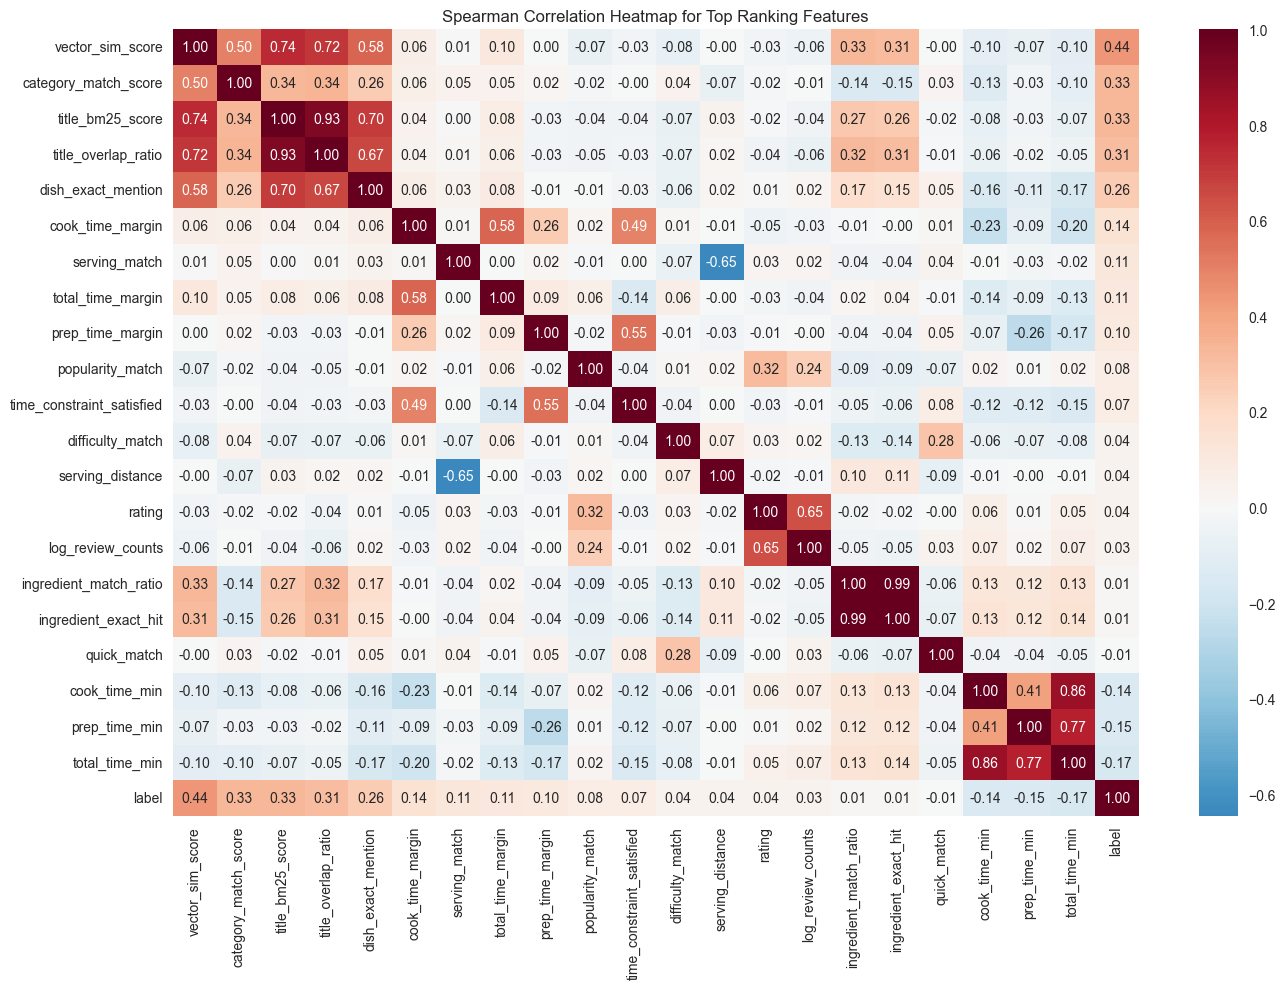

In [19]:
# =========================
# Kiểm tra dữ liệu đầu vào
# =========================

# required_raw_cols = các cột bắt buộc phải có trước khi tạo feature
required_raw_cols = [
    "query", "dish_name", "recipe_id", "ingredients", "category",
    "difficulty", "views", "prep_time_min", "cook_time_min",
    "servings_bin", "popularity",
]

missing_raw_cols = [col for col in required_raw_cols if col not in df.columns]
if missing_raw_cols:
    raise KeyError(f"Thiếu các cột bắt buộc trước khi tạo feature: {missing_raw_cols}")


# =========================
# Tạo các cột text cơ bản
# =========================

df = df.copy()

# recipe_text = text tổng hợp của recipe, dùng cho TF-IDF similarity
df["recipe_text"] = df.apply(build_recipe_text, axis=1)

# Chuẩn hóa text của tên món và query
df["dish_name_norm"] = df["dish_name"].map(normalize_text)
df["query_norm"] = df["query"].map(normalize_text)

# title_tokens / query_tokens = token hóa title và query
df["title_tokens"] = df["dish_name"].map(tokenize)
df["query_tokens"] = df["query"].map(tokenize)

created_feature_cols = [
    "recipe_text",
    "dish_name_norm",
    "query_norm",
    "title_tokens",
    "query_tokens",
]

missing_created_cols = [col for col in created_feature_cols if col not in df.columns]
if missing_created_cols:
    raise KeyError(f"Không tạo được các cột feature cơ bản: {missing_created_cols}")


# =========================
# Parse query một lần
# =========================

# Parse mỗi query đúng 1 lần để tránh chạy lặp lại nhiều hàm giống nhau
query_feature_df = pd.DataFrame(
    [parse_query_constraints(q) for q in df["query"].drop_duplicates()]
)

# Merge các thông tin parse từ query vào bảng chính
df = df.merge(
    query_feature_df[
        [
            "query",
            "servings_target",
            "difficulty_target",
            "prep_time_limit_min",
            "cook_time_limit_min",
            "total_time_limit_min",
            "time_limit_min",
            "max_ingredients",
            "style_tags",
            "categories",
        ]
    ],
    on="query",
    how="left",
)

# Đổi tên cho rõ nghĩa hơn khi dùng trong feature engineering
df = df.rename(
    columns={
        "servings_target": "requested_people",
        "difficulty_target": "query_difficulty_target",
    }
)


# =========================
# Build retrieval features
# =========================

# recipe_lookup = bảng recipe duy nhất theo recipe_id,
# dùng để tạo corpus cho BM25 và TF-IDF
recipe_lookup = df[["recipe_id", "dish_name", "recipe_text"]].drop_duplicates("recipe_id").copy()
recipe_lookup["title_tokens"] = recipe_lookup["dish_name"].map(tokenize)

# title_corpus = dictionary {recipe_id: tokenized_title}
title_corpus = recipe_lookup.set_index("recipe_id")["title_tokens"].to_dict()

# Chuẩn bị tham số BM25 trên toàn bộ title corpus
bm25_params = build_bm25(list(title_corpus.values()))

# recipe_text_by_id = dictionary {recipe_id: recipe_text}
recipe_text_by_id = recipe_lookup.set_index("recipe_id")["recipe_text"].to_dict()

# query_texts = danh sách query duy nhất, dùng để fit TF-IDF
query_texts = df["query"].drop_duplicates().tolist()

# TF-IDF dùng để tính semantic similarity giữa query và recipe_text
tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_features=20000,
)
tfidf.fit(query_texts + list(recipe_text_by_id.values()))

query_tfidf_map = {q: tfidf.transform([q]) for q in query_texts}
recipe_tfidf_map = {rid: tfidf.transform([text]) for rid, text in recipe_text_by_id.items()}


# =========================
# Numeric metadata features
# =========================

# serving_mid = số người ăn đại diện, lấy từ servings_bin
df["serving_mid"] = df["servings_bin"].map(parse_servings_bin)

# total_time_min = tổng thời gian chuẩn bị + nấu
df["total_time_min"] = df["prep_time_min"].fillna(0) + df["cook_time_min"].fillna(0)

# Chuẩn hóa các cột số
df["difficulty_level"] = pd.to_numeric(df["difficulty"], errors="coerce").fillna(0)
df["views"] = pd.to_numeric(df["views"], errors="coerce").fillna(0)

# log_review_counts = log views để giảm độ lệch phân phối
df["log_review_counts"] = np.log1p(df["views"])

# rating = ánh xạ popularity text -> số
df["rating"] = df["popularity"].map(POPULARITY_MAP).fillna(0).astype(float)

# Time margins = nếu dương thì recipe vẫn nằm trong giới hạn thời gian query
df["prep_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["prep_time_min"],
    0.0,
)

df["cook_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["cook_time_min"],
    0.0,
)

df["total_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["total_time_min"],
    0.0,
)


# =========================
# Matching features
# =========================

# title_bm25_score = mức độ khớp từ vựng giữa query và title recipe
df["title_bm25_score"] = [
    bm25_score(qt, title_corpus[rid], bm25_params)
    for qt, rid in zip(df["query_tokens"], df["recipe_id"])
]

# vector_sim_score = độ tương đồng TF-IDF cosine giữa query và recipe_text
df["vector_sim_score"] = [
    float(cosine_similarity(query_tfidf_map[q], recipe_tfidf_map[rid])[0, 0])
    for q, rid in zip(df["query"], df["recipe_id"])
]

# category_match_score = mức độ khớp category giữa query và recipe
df["category_match_score"] = [
    query_category_signal(q, c)
    for q, c in zip(df["query"], df["category"])
]

# title_overlap_ratio = tỷ lệ token query xuất hiện trong title
df["title_overlap_ratio"] = [
    len(set(qt) & set(tt)) / max(len(set(tt)), 1)
    for qt, tt in zip(df["query_tokens"], df["title_tokens"])
]

# dish_exact_mention = nếu query và title trùng >= 2 token thì xem như nhắc tên món khá rõ
df["dish_exact_mention"] = [
    float(len(set(qt) & set(tt)) >= 2)
    for qt, tt in zip(df["query_tokens"], df["title_tokens"])
]

# ingredient_features = trả về (ingredient_match_ratio, ingredient_exact_hit)
ingredient_features_list = [
    ingredient_features(q, ingredients)
    for q, ingredients in zip(df["query"], df["ingredients"])
]
df["ingredient_match_ratio"] = [x[0] for x in ingredient_features_list]
df["ingredient_exact_hit"] = [x[1] for x in ingredient_features_list]


# =========================
# Constraint satisfaction features
# =========================

# serving_match = query và recipe có số người ăn gần nhau hay không
df["serving_match"] = (
    df["requested_people"].notna()
    & df["serving_mid"].notna()
    & (np.abs(df["requested_people"] - df["serving_mid"]) <= 1.0)
).astype(float)

# serving_distance = khoảng cách giữa số người mong muốn và số người phục vụ của recipe
df["serving_distance"] = np.where(
    df["requested_people"].notna() & df["serving_mid"].notna(),
    np.abs(df["requested_people"] - df["serving_mid"]),
    99.0,
)

# difficulty_match = recipe có đúng độ khó query yêu cầu hay không
df["difficulty_match"] = (
    df["query_difficulty_target"].notna()
    & (df["query_difficulty_target"] == df["difficulty_level"])
).astype(float)

# category_exact_hit = category match hoàn toàn
df["category_exact_hit"] = (df["category_match_score"] >= 1.0).astype(float)

# time_constraint_satisfied = recipe có thỏa điều kiện thời gian hay không
df["time_constraint_satisfied"] = np.where(
    df["time_limit_min"].notna(),
    (df["prep_time_min"].fillna(10**6) <= df["time_limit_min"])
    & (df["cook_time_min"].fillna(10**6) <= df["time_limit_min"]),
    0,
).astype(float)

# quick_match = ưu tiên món nhanh nếu query có nhắc nhanh / ít thời gian
df["quick_match"] = np.where(
    df["query_norm"].str.contains(r"\bnhanh\b|it thoi gian|lam gap", regex=True),
    1.0 / (1.0 + df["total_time_min"]),
    0.0,
)

# popularity_match = ưu tiên món phổ biến nếu query có style "pho_bien"
df["popularity_match"] = np.where(
    df["style_tags"].fillna("").str.contains("pho_bien"),
    (df["rating"] >= 4).astype(float),
    0.0,
)


# =========================
# Final feature lists
# =========================

# corr_feature_cols = các feature dùng để xem tương quan với label
corr_feature_cols = [
    "title_bm25_score",
    "title_overlap_ratio",
    "dish_exact_mention",
    "ingredient_match_ratio",
    "ingredient_exact_hit",
    "category_match_score",
    "vector_sim_score",
    "prep_time_min",
    "cook_time_min",
    "total_time_min",
    "prep_time_margin",
    "cook_time_margin",
    "total_time_margin",
    "serving_match",
    "serving_distance",
    "difficulty_match",
    "time_constraint_satisfied",
    "rating",
    "log_review_counts",
    "quick_match",
    "popularity_match",
]

# feature_cols = danh sách feature cuối cùng đưa vào model
feature_cols = corr_feature_cols + [
    "serving_mid",
    "requested_people",
    "difficulty_level",
    "time_limit_min",
    "category_exact_hit",
]

# Tính tương quan Spearman giữa feature và label
corr_df = df[corr_feature_cols + ["label"]].corr(method="spearman")
label_corr = corr_df["label"].drop("label").sort_values(ascending=False)
# Vẽ heatmap cho các feature quan trọng nhất theo tương quan
plt.figure(figsize=(14, 10))
heatmap_cols = list(label_corr.index) + ["label"]
sns.heatmap(
    df[heatmap_cols].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Spearman Correlation Heatmap for Top Ranking Features")
plt.tight_layout()
plt.show()


## Correlation Analysis

The Spearman correlation heatmap shows that retrieval-based features provide the strongest ranking signal. In particular, `vector_sim_score` has the highest correlation with the relevance label (`0.44`), followed by `category_match_score` and `title_bm25_score` (both `0.33`), and `title_overlap_ratio` (`0.31`). This suggests that semantic similarity, lexical matching, and category alignment are the most informative factors for ranking recipes.

The heatmap also reveals strong redundancy among several text-matching features. For example, `title_bm25_score` and `title_overlap_ratio` are very highly correlated (`0.93`), while `vector_sim_score` is also strongly correlated with both of them (`0.74` and `0.72`). Similarly, `ingredient_match_ratio` and `ingredient_exact_hit` are almost identical in behavior (`0.99`). These results indicate that some features capture overlapping information and may be simplified in future feature selection experiments.

In contrast, constraint-based features such as `serving_match`, `difficulty_match`, `time_constraint_satisfied`, and popularity-related features show relatively weak direct correlations with the label. Time features such as `cook_time_min`, `prep_time_min`, and `total_time_min` are also strongly correlated with each other, especially `cook_time_min` and `total_time_min` (`0.86`). Overall, the current model appears to rely mainly on retrieval relevance signals, while rule-based constraint features provide weaker but potentially complementary information.


In [20]:
# feature_groups = {
#     "retrieval_core": [
#         "vector_sim_score",
#         "title_bm25_score",
#     ],
#     "category_alignment": [
#         "category_match_score",
#         "category_exact_hit",
#     ],
#     "time_constraint": [
#         "time_constraint_satisfied",
#     ],
#     "raw_duration": [
#         "cook_time_min",
#         "prep_time_min",
#         "total_time_min",
#     ],
#     "user_fit_constraints": [
#         "serving_match",
#         "serving_distance",
#         "serving_mid",
#         "requested_people",
#         "difficulty_match",
#         "difficulty_level",
#     ],
#     "compact": [
#         "vector_sim_score",
#         "title_bm25_score",
#         "category_match_score",
#         "time_constraint_satisfied",
#         "total_time_min",
#         "serving_match",
#         "difficulty_match",
#     ],
#     "full": [
#         "title_bm25_score",
#         "ingredient_match_ratio",
#         "category_match_score",
#         "cook_time_min",
#         "prep_time_min",
#         "serving_match",
#         "serving_mid",
#         "rating",
#         "vector_sim_score",
#         "total_time_min",
#         "difficulty_level",
#         "serving_distance",
#         "requested_people",
#         "log_review_counts",
#         "time_constraint_satisfied",
#         "difficulty_match",
#         "ingredient_exact_hit",
#         "category_exact_hit",
#     ],
# }

# feature_cols = [
#           "title_bm25_score",
#         "ingredient_match_ratio",
#         "category_match_score",
#         "cook_time_min",
#         "prep_time_min",
#         "serving_match",
#         "serving_mid",
#         "rating",
#         "vector_sim_score",
#         "total_time_min",
#         "difficulty_level",
#         "serving_distance",
#         "requested_people",
#         "log_review_counts",
#         "time_constraint_satisfied",
#         "difficulty_match",
#         "ingredient_exact_hit",
#         "category_exact_hit",
# ]

model_df = df.copy()
model_df[feature_cols] = model_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

query_table = (
    model_df.groupby("query")
    .agg(avg_label=("label", "mean"), n_candidates=("query", "size"))
    .reset_index()
)

train_queries, temp_queries = train_test_split(
    query_table["query"],
    test_size=0.30,
    random_state=RANDOM_STATE,
)
val_queries, test_queries = train_test_split(
    temp_queries,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

def make_split(split_queries):
    split_df = model_df[model_df["query"].isin(split_queries)].copy()
    split_df = split_df.sort_values(["query", "recipe_id"]).reset_index(drop=True)
    X = split_df[feature_cols]
    y = split_df["label"].astype(float)
    group = split_df.groupby("query").size().tolist()
    return split_df, X, y, group

train_df, X_train, y_train, group_train = make_split(train_queries)
val_df, X_val, y_val, group_val = make_split(val_queries)
test_df, X_test, y_test, group_test = make_split(test_queries)

print("Train queries:", train_df["query"].nunique(), "rows:", len(train_df))
print("Val queries:", val_df["query"].nunique(), "rows:", len(val_df))
print("Test queries:", test_df["query"].nunique(), "rows:", len(test_df))
print("Feature count:", len(feature_cols))
        


Train queries: 175 rows: 2625
Val queries: 37 rows: 555
Test queries: 38 rows: 570
Feature count: 26


In [21]:
def compute_group_metrics(eval_df, score_col="pred_score", top_ks=(5, 10)):
    ndcg_store = defaultdict(list)
    mrr_store = []
    hit_store = {k: [] for k in top_ks}

    for query, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            ndcg_k = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(ndcg_k))

        relevant_positions = np.where(group["label"].to_numpy() >= 4)[0]
        if len(relevant_positions) > 0:
            mrr_store.append(1.0 / (relevant_positions[0] + 1))
        else:
            mrr_store.append(0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 4).any()))

    metrics = {}
    for k in top_ks:
        metrics[f"NDCG@{k}"] = float(np.mean(ndcg_store[k]))
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics


In [22]:
ranker = XGBRanker(
    objective="rank:pairwise",
    eval_metric=["ndcg@5", "ndcg@10"],
    learning_rate=0.05,
    n_estimators=400,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
)

start_time = time.time()
ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_group=[group_train, group_val],
    verbose=False,
)
train_seconds = time.time() - start_time

print(f"Training finished in {train_seconds:.2f} seconds")
        


Training finished in 1.36 seconds


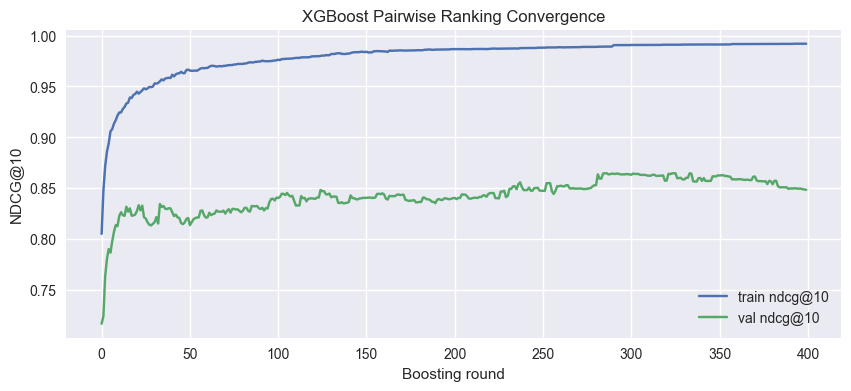

In [23]:
evals_result = ranker.evals_result()

plt.figure(figsize=(10, 4))
plt.plot(evals_result["validation_0"]["ndcg@10"], label="train ndcg@10")
plt.plot(evals_result["validation_1"]["ndcg@10"], label="val ndcg@10")
plt.title("XGBoost Pairwise Ranking Convergence")
plt.xlabel("Boosting round")
plt.ylabel("NDCG@10")
plt.legend()
plt.show()
        


In [24]:
test_pred_start = time.time()
test_df = test_df.copy()
test_df["pred_score"] = ranker.predict(X_test)
infer_seconds = time.time() - test_pred_start

test_metrics = compute_group_metrics(test_df, score_col="pred_score")

comparison_df = pd.DataFrame([
    {"model": "XGBoost rank:pairwise", **test_metrics, "train_seconds": train_seconds, "infer_seconds": infer_seconds},
])
comparison_df
        


,model,NDCG@5,NDCG@10,MRR,HIT@5,HIT@10,train_seconds,infer_seconds
0,XGBoost rank:pairwise,0.805496,0.860331,0.496711,0.684211,0.710526,1.36468,0.025666


,feature,importance
5,category_match_score,0.081858
16,time_constraint_satisfied,0.048909
25,category_exact_hit,0.048820
13,serving_match,0.047529
23,difficulty_level,0.046380
14,serving_distance,0.045011
6,vector_sim_score,0.044300
10,prep_time_margin,0.042583
12,total_time_margin,0.039372
20,popularity_match,0.038939


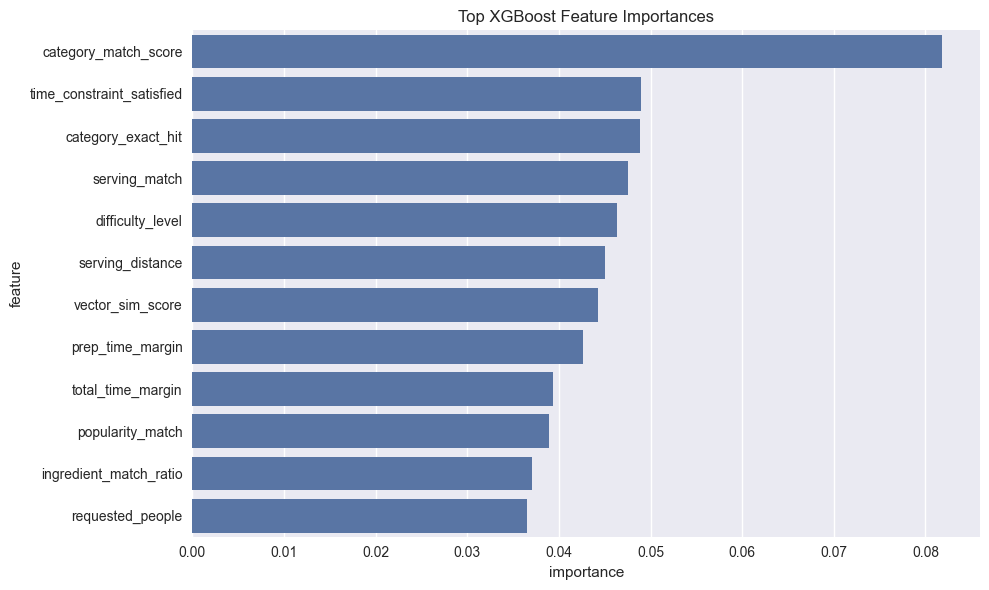

In [25]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": ranker.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(12), x="importance", y="feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()
        


In [26]:
ablations = {
    "full": feature_cols,
    "without_support_signals": [c for c in feature_cols if c not in {"rating", "log_review_counts"}],
    "without_constraint_flags": [c for c in feature_cols if c not in {"time_constraint_satisfied", "difficulty_match", "ingredient_exact_hit", "category_exact_hit"}],
}

ablation_rows = []
for ablation_name, cols in ablations.items():
    local_train = train_df[cols]
    local_val = val_df[cols]
    local_test = test_df[cols]

    local_ranker = XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg@10",
        learning_rate=0.05,
        n_estimators=250,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )
    local_ranker.fit(
        local_train,
        y_train,
        group=group_train,
        eval_set=[(local_val, y_val)],
        eval_group=[group_val],
        verbose=False,
    )
    local_scores = local_ranker.predict(local_test)
    local_eval = test_df.copy()
    local_eval["pred_score"] = local_scores
    metrics = compute_group_metrics(local_eval, score_col="pred_score")
    ablation_rows.append({"setting": ablation_name, **metrics, "n_features": len(cols)})

pd.DataFrame(ablation_rows).sort_values("NDCG@10", ascending=False)
        


,setting,NDCG@5,NDCG@10,MRR,HIT@5,HIT@10,n_features
0,full,0.810359,0.864095,0.529605,0.684211,0.710526,26
1,without_support_signals,0.808718,0.863730,0.522368,0.684211,0.710526,24
2,without_constraint_flags,0.780107,0.849990,0.509942,0.657895,0.710526,22
